# Step 0.3 — Investigate annotation sources

INbreast ships with several overlapping annotation sources. Two of them feed this project directly, and each exists in two independent versions that don't perfectly agree:

1. **Pectoral muscle masks** — the GitHub LabelMe-JSON set (Aliniya 2023, 202 files) used by Step 1.1, vs. the Kaggle Apple-plist XML set (INESC Porto, original 2012 INbreast release, 201 files). Audited in **Sections 1–4**.
2. **Lesion annotations** — the OsiriX XML files (343 annotation files, 107 of which contain a `Mass` polygon) used by Step 1.2, vs. the `INbreast.xls` `Mass` checkbox column (108 files flagged). Audited in **Sections 5–6**.

In both cases the two sources are reasonable-sounding but disagree on a small number of files. The point of this notebook is to make those disagreements visible and to justify the source the pipeline uses.

**This notebook is read-only.** It does not save any files — the conclusions reached here are recorded in the project report (`report/main.tex` §4) and acted on by Step 1.1 (which pectoral-mask source to load) and Step 1.2 (which lesion-annotation source to extract from). Section 7 at the end ties both audits together.


## 0. Setup — imports, paths and helpers

Everything used by both audits sits in the three setup cells below — imports and paths first, then the parsers and the DICOM loader, then small file-lookup helpers. The DICOM loader uses the same 1st/99th-percentile-clip recipe as Step 0.1 and Step 1.1. The first cell prints the three source directories so a missing or mis-typed path is caught immediately rather than failing silently three cells later.


In [1]:
# --- Imports + paths + path-existence check ---
import json
import plistlib
import re
from pathlib import Path

import numpy as np
import pydicom
import matplotlib.pyplot as plt
from skimage.draw import polygon as sk_polygon

ROOT       = Path("..")
DICOM_DIR  = ROOT / "data" / "raw" / "inbreast" / "ALL-IMGS"
GH_DIR     = ROOT / "data" / "raw" / "muscle_masks_for_raw_data"
KX_DIR     = ROOT / "data" / "raw" / "kaggle_inbreast" / "PectoralMuscle" / "Pectoral Muscle XML"

print(f"DICOM dir   : {DICOM_DIR}    exists={DICOM_DIR.exists()}")
print(f"GitHub dir  : {GH_DIR}    exists={GH_DIR.exists()}")
print(f"Kaggle dir  : {KX_DIR}    exists={KX_DIR.exists()}")


DICOM dir   : ../data/raw/inbreast/ALL-IMGS    exists=True
GitHub dir  : ../data/raw/muscle_masks_for_raw_data    exists=True
Kaggle dir  : ../data/raw/kaggle_inbreast/PectoralMuscle/Pectoral Muscle XML    exists=True


In [2]:
# --- Parsers + DICOM loader + polygon-to-mask rasteriser ---
NUM_RE = re.compile(r"[-+]?\d*\.?\d+")


def load_dicom_norm(path: Path) -> np.ndarray:
    """Read a DICOM and normalise to [0, 1] via 1st/99th-percentile clip.

    Same loader as Step 0.1 / Step 1.1.  No VOI-LUT application and no
    MONOCHROME1 inversion: all 410 INbreast files are MONOCHROME2 with
    no VOI metadata in the headers (audited), so both branches were
    no-ops and have been removed."""
    ds = pydicom.dcmread(str(path))
    img = ds.pixel_array.astype(np.float32)
    lo, hi = np.percentile(img, (1, 99))
    img = np.clip(img, lo, hi)
    img = (img - lo) / (hi - lo + 1e-8)
    return img


def gh_polygon(path: Path) -> np.ndarray:
    """Parse a GitHub LabelMe JSON and return an Nx2 array of (x, y) polygon vertices."""
    with open(path) as f:
        d = json.load(f)
    if not d.get("shapes"):
        return np.zeros((0, 2), dtype=np.float64)
    pts = d["shapes"][0].get("points", [])
    return np.array([(float(x), float(y)) for x, y in pts], dtype=np.float64)


def kx_polygon(path: Path) -> np.ndarray:
    """Parse a Kaggle Apple-plist XML and return an Nx2 array of (x, y) polygon vertices."""
    with open(path, "rb") as f:
        d = plistlib.load(f)
    out = []
    for s in d.get("ROIPoints", []):
        nums = NUM_RE.findall(str(s))
        if len(nums) >= 2:
            out.append((float(nums[0]), float(nums[1])))
    return np.array(out, dtype=np.float64)


def polygon_to_mask(pts: np.ndarray, shape_hw: tuple) -> np.ndarray:
    """Rasterise an Nx2 (x, y) polygon into a binary boolean mask."""
    if pts.shape[0] < 3:
        return np.zeros(shape_hw, dtype=bool)
    rr, cc = sk_polygon(pts[:, 1], pts[:, 0], shape_hw)
    m = np.zeros(shape_hw, dtype=bool)
    m[rr, cc] = True
    return m


In [3]:
# --- File-lookup helpers ---
def lead_id(name: str) -> str:
    """Extract the leading numeric file_id from a filename."""
    m = re.match(r"(\d+)", name)
    return m.group(1) if m else None


def find_dicom(file_id: str) -> Path:
    """Locate the .dcm file for a given file_id (the leading number of its name)."""
    matches = list(DICOM_DIR.glob(f"{file_id}_*.dcm"))
    return matches[0] if matches else None


def gh_path_for(file_id: str) -> Path:
    matches = list(GH_DIR.glob(f"{file_id}_*.json"))
    return matches[0] if matches else None


def kx_path_for(file_id: str) -> Path:
    p = KX_DIR / f"{file_id}_muscle.xml"
    return p if p.exists() else None


## 1. Inventory — which file_ids does each source cover?

A first sanity check: how many file_ids are in each source, how many appear in both, and which ones are unique to one source. This sets up the rest of the comparison.

In [4]:
gh_ids = {lead_id(p.name) for p in GH_DIR.glob("*.json")}
kx_ids = {lead_id(p.name) for p in KX_DIR.glob("*_muscle.xml")}

common  = sorted(gh_ids & kx_ids)
gh_only = sorted(gh_ids - kx_ids)
kx_only = sorted(kx_ids - gh_ids)

print(f"GitHub (Aliniya 2023) total : {len(gh_ids)}")
print(f"Kaggle (INESC Porto)  total : {len(kx_ids)}")
print(f"Files in BOTH sources       : {len(common)}")
print(f"GitHub-only                 : {len(gh_only)}    ids = {gh_only}")
print(f"Kaggle-only                 : {len(kx_only)}    ids = {kx_only}")

# For each unique file_id, check the DICOM view (MLO/ML vs CC)
print()
print("Unique files and their DICOM view types:")
for fid in gh_only + kx_only:
    dcm = find_dicom(fid)
    if dcm is None:
        print(f"  {fid}: no DICOM found")
        continue
    name = dcm.name
    view = "MLO/ML" if "_ML_" in name or "_MLO_" in name else "CC"
    src = "GitHub" if fid in gh_only else "Kaggle"
    print(f"  {fid}  src={src}  view={view}  ({name})")


GitHub (Aliniya 2023) total : 202
Kaggle (INESC Porto)  total : 201
Files in BOTH sources       : 199
GitHub-only                 : 3    ids = ['20587492', '20587518', '50994273']
Kaggle-only                 : 2    ids = ['24055024', '53582737']

Unique files and their DICOM view types:
  20587492  src=GitHub  view=MLO/ML  (20587492_d571b5880ad2a016_MG_R_ML_ANON.dcm)
  20587518  src=GitHub  view=MLO/ML  (20587518_d571b5880ad2a016_MG_L_ML_ANON.dcm)
  50994273  src=GitHub  view=CC  (50994273_cc9e66c5b31baab8_MG_R_CC_ANON.dcm)
  24055024  src=Kaggle  view=MLO/ML  (24055024_2f1104b3cda7f145_MG_R_ML_ANON.dcm)
  53582737  src=Kaggle  view=MLO/ML  (53582737_465aa5ec1b59efc6_MG_L_ML_ANON.dcm)


### 1.1 What the inventory shows

The two sources overlap on the majority of file_ids but each has a small set the other doesn't:

- The "GitHub-only" file `50994273` is interesting — its DICOM is a **CC view**, not MLO/ML. CC views typically don't show pectoral muscle, so the original INbreast annotators (Kaggle source) didn't include it. The GitHub annotator nonetheless drew a polygon, presumably because they spotted a sliver of muscle that the original annotators considered too small to bother with.
- All the other unique file_ids on either side are legitimate MLO/ML views — the two sources just happened to include or omit different subsets.
- There are also a handful of MLO/ML views (≈4 in total) that have no pectoral mask in **either** source. Not all MLO views were annotated.

## 2. Visual comparison — 5 files annotated in both sources

For 5 sample MLO/ML files that both sources annotated, plot:
- The full preprocessed DICOM by itself (left column)
- The full DICOM with the GitHub mask in red (middle column)
- The full DICOM with the Kaggle mask in blue (right column)

The full image is shown here so the pectoral annotation can be judged in the context of the whole mammogram.

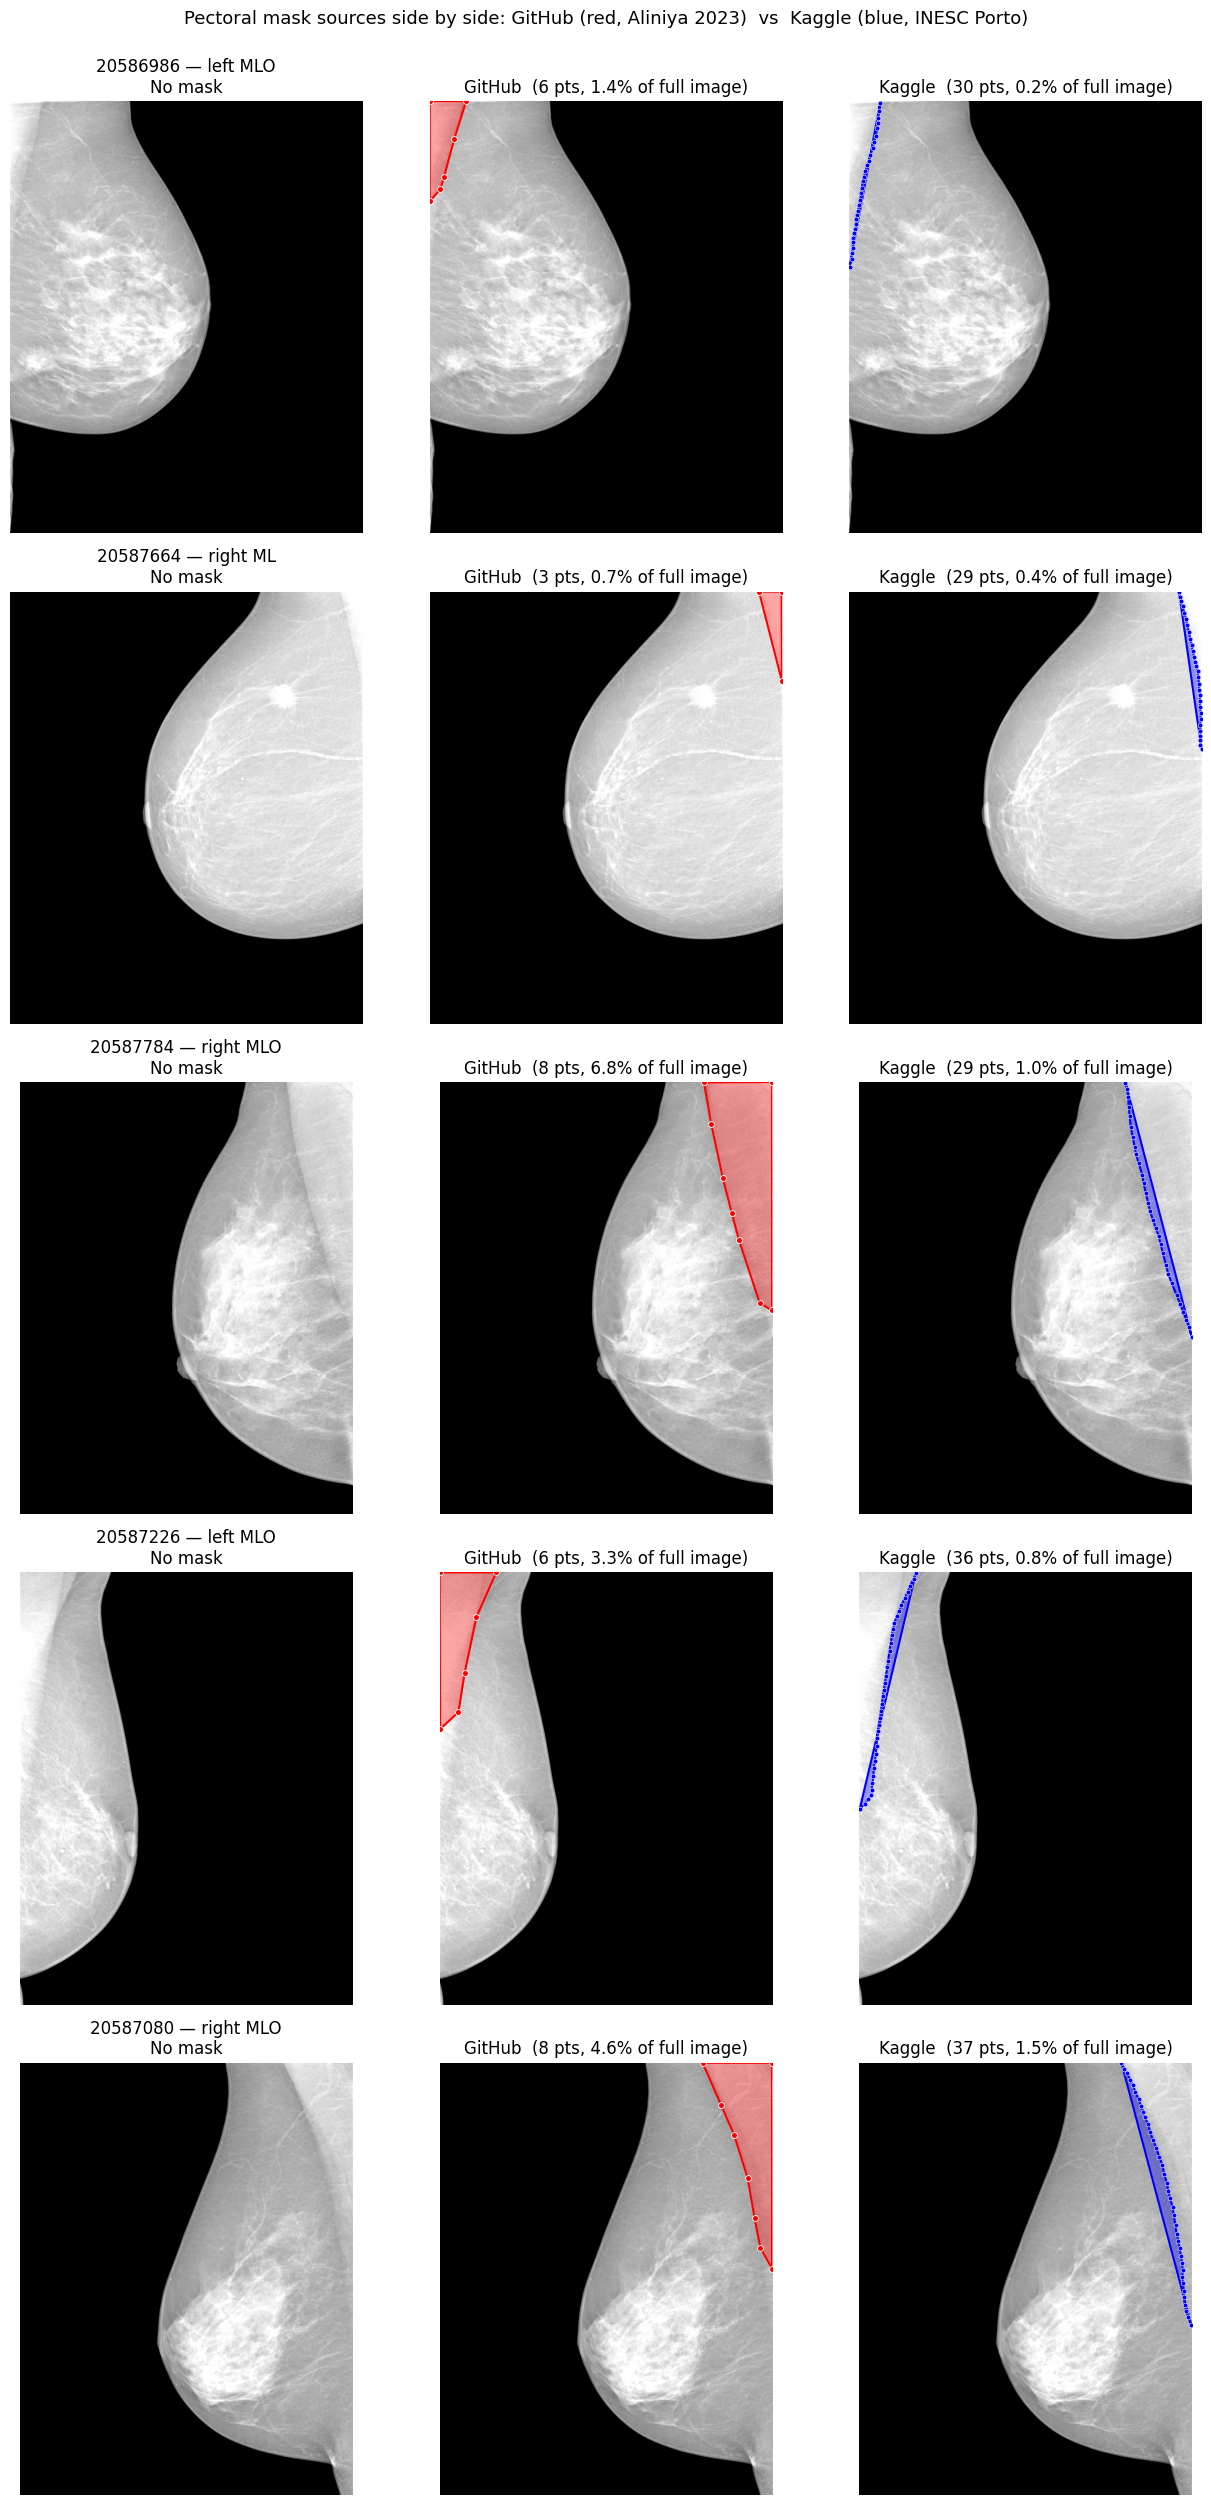

In [5]:
# Five common file_ids picked to span left/right laterality and different coverage gaps.
COMMON_SAMPLES = [
    ("20586986", "left MLO"),
    ("20587664", "right ML"),
    ("20587784", "right MLO"),
    ("20587226", "left MLO"),
    ("20587080", "right MLO"),
]

# Sanity check: every file_id should be in `common`
for fid, _ in COMMON_SAMPLES:
    assert fid in common, f"{fid} not in the common set!"


def crop_to_masks(img, *masks, pad=80):
    """Crop image around the union of the supplied masks (plus a small padding)."""
    H, W = img.shape
    union = np.zeros((H, W), dtype=bool)
    for m in masks:
        union |= m
    ys, xs = np.where(union)
    if len(ys) == 0:
        return img, 0, 0
    y0 = max(0, ys.min() - pad); y1 = min(H, ys.max() + pad)
    x0 = max(0, xs.min() - pad); x1 = min(W, xs.max() + pad)
    return img[y0:y1, x0:x1], y0, x0


fig, axes = plt.subplots(len(COMMON_SAMPLES), 3, figsize=(13, 5 * len(COMMON_SAMPLES)))

for row, (fid, view_note) in enumerate(COMMON_SAMPLES):
    img = load_dicom_norm(find_dicom(fid))
    H, W = img.shape

    gh_pts = gh_polygon(gh_path_for(fid))
    kx_pts = kx_polygon(kx_path_for(fid))
    gh_mask = polygon_to_mask(gh_pts, (H, W))
    kx_mask = polygon_to_mask(kx_pts, (H, W))

    # Show the whole mammogram rather than a crop around the pectoral masks.
    img_c = img
    gh_c = gh_mask
    kx_c = kx_mask

    # Panel 1: image only
    ax = axes[row, 0]
    ax.imshow(img_c, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"{fid} — {view_note}\nNo mask")
    ax.axis("off")

    # Panel 2: GitHub mask
    ax = axes[row, 1]
    ax.imshow(img_c, cmap="gray", vmin=0, vmax=1)
    overlay = np.zeros((*gh_c.shape, 4), dtype=np.float32)
    overlay[..., 0] = 1.0
    overlay[..., 3] = 0.35 * gh_c.astype(np.float32)
    ax.imshow(overlay)
    pts_local = gh_pts.copy()
    if pts_local.shape[0] >= 3:
        closed = np.vstack([pts_local, pts_local[:1]])
        ax.plot(closed[:, 0], closed[:, 1], "r-", linewidth=1.5)
        ax.scatter(pts_local[:, 0], pts_local[:, 1], c="red", s=18,
                   zorder=5, edgecolor="white", linewidth=0.6)
    ax.set_title(f"GitHub  ({gh_pts.shape[0]} pts, {100*gh_c.sum()/gh_c.size:.1f}% of full image)")
    ax.axis("off")

    # Panel 3: Kaggle mask
    ax = axes[row, 2]
    ax.imshow(img_c, cmap="gray", vmin=0, vmax=1)
    overlay = np.zeros((*kx_c.shape, 4), dtype=np.float32)
    overlay[..., 2] = 1.0
    overlay[..., 3] = 0.35 * kx_c.astype(np.float32)
    ax.imshow(overlay)
    pts_local = kx_pts.copy()
    if pts_local.shape[0] >= 3:
        closed = np.vstack([pts_local, pts_local[:1]])
        ax.plot(closed[:, 0], closed[:, 1], "b-", linewidth=1.5)
        ax.scatter(pts_local[:, 0], pts_local[:, 1], c="blue", s=12,
                   zorder=5, edgecolor="white", linewidth=0.4)
    ax.set_title(f"Kaggle  ({kx_pts.shape[0]} pts, {100*kx_c.sum()/kx_c.size:.1f}% of full image)")
    ax.axis("off")

plt.suptitle(
    "Pectoral mask sources side by side: GitHub (red, Aliniya 2023)  vs  Kaggle (blue, INESC Porto)",
    fontsize=13, y=1.0,
)
plt.tight_layout()
plt.show()


### 2.1 What the side-by-side shows

Two consistent patterns across all five files:

1. **Different annotation philosophy.** The GitHub source draws *triangular regional masks* that fill the upper-corner area where the pectoral muscle is. The Kaggle source draws *muscle-boundary outlines* — narrow polygons that hug the actual muscle tissue.
2. **Different polygon detail.** GitHub uses 3–8 vertices per polygon (coarse approximation); Kaggle uses 20–40 vertices (fine boundary trace).

For our pipeline's purpose (zero out the masked region before breast-mask + CLAHE in Step 1.1), either approach works. The GitHub mask is more conservative — it removes the entire upper-corner region, which includes the muscle plus some surrounding background. The Kaggle mask is more anatomically precise — it removes only the muscle tissue. The visual difference looks larger than the practical effect on downstream classifiers, because the breast mask handles the surrounding non-breast pixels regardless of which pectoral mask is used.

## 3. Source-unique files

Five files are only annotated in one of the two sources:
- **GitHub-only (3 files)**: `20587492`, `20587518`, `50994273`
- **Kaggle-only (2 files)**: `24055024`, `53582737`

For each, we plot the full DICOM with the available mask overlay so we can see what that single source captured in the context of the whole mammogram.

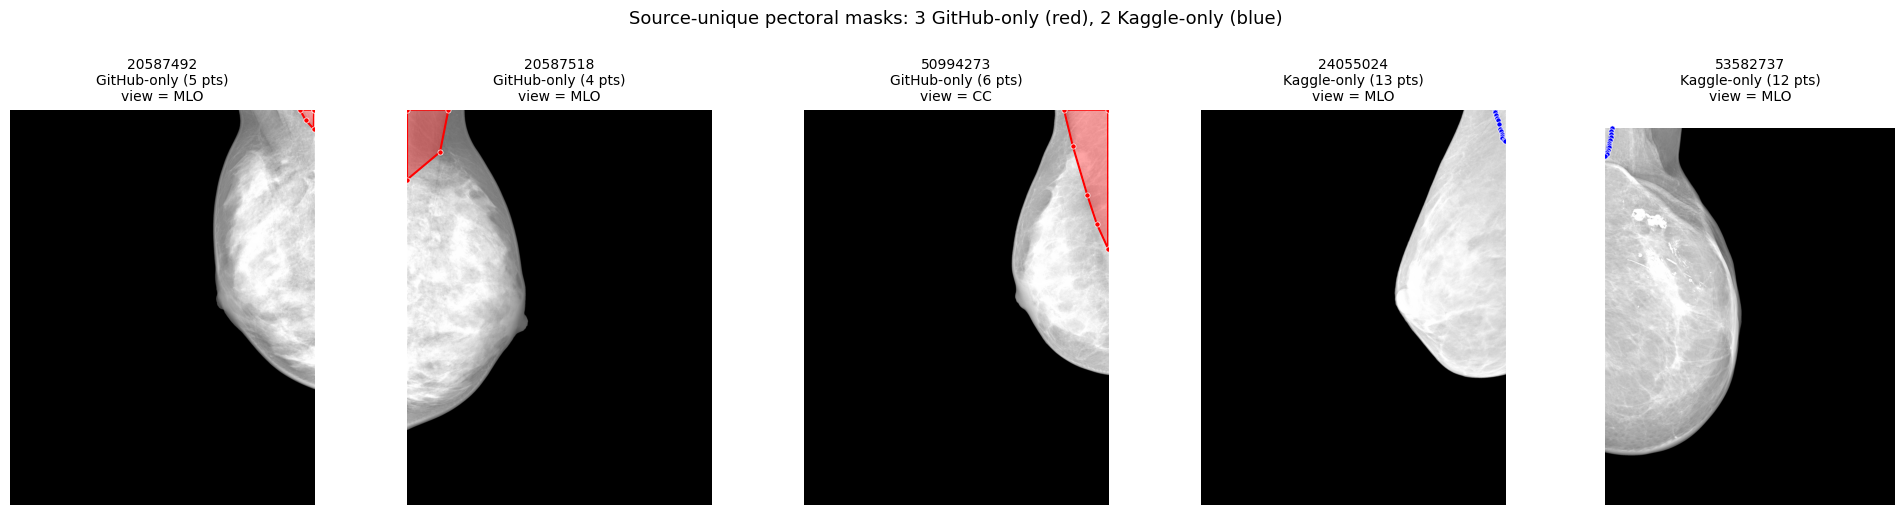

In [6]:
UNIQUE_GH = ["20587492", "20587518", "50994273"]
UNIQUE_KX = ["24055024", "53582737"]

samples = [(fid, "GitHub", "red") for fid in UNIQUE_GH] + \
          [(fid, "Kaggle", "blue") for fid in UNIQUE_KX]

fig, axes = plt.subplots(1, len(samples), figsize=(4 * len(samples), 5))

for ax, (fid, src, colour) in zip(axes, samples):
    dcm = find_dicom(fid)
    if dcm is None:
        ax.text(0.5, 0.5, f"{fid}\n(no DICOM)", ha="center", va="center")
        ax.axis("off")
        continue
    img = load_dicom_norm(dcm)
    H, W = img.shape

    if src == "GitHub":
        pts = gh_polygon(gh_path_for(fid))
    else:
        pts = kx_polygon(kx_path_for(fid))
    mask = polygon_to_mask(pts, (H, W))

    # Show the whole mammogram rather than a crop around the available mask.
    img_c = img
    mask_c = mask

    ax.imshow(img_c, cmap="gray", vmin=0, vmax=1)
    overlay = np.zeros((*mask_c.shape, 4), dtype=np.float32)
    if colour == "red":
        overlay[..., 0] = 1.0
    else:
        overlay[..., 2] = 1.0
    overlay[..., 3] = 0.35 * mask_c.astype(np.float32)
    ax.imshow(overlay)
    pts_local = pts.copy()
    if pts_local.shape[0] >= 3:
        closed = np.vstack([pts_local, pts_local[:1]])
        ax.plot(closed[:, 0], closed[:, 1], color=colour, linewidth=1.5)
        ax.scatter(pts_local[:, 0], pts_local[:, 1], c=colour, s=14,
                   zorder=5, edgecolor="white", linewidth=0.5)

    view = "MLO" if "_ML_" in dcm.name or "_MLO_" in dcm.name else "CC"
    ax.set_title(
        f"{fid}\n{src}-only ({pts.shape[0]} pts)\nview = {view}",
        fontsize=10,
    )
    ax.axis("off")

plt.suptitle(
    "Source-unique pectoral masks: 3 GitHub-only (red), 2 Kaggle-only (blue)",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()


### 3.1 What the source-unique panels show

- The first three panels (GitHub-only) show the masks Aliniya 2023 added that the original INESC Porto annotation missed. Of particular note is **`50994273`**, which is a **CC view** (no pectoral muscle should be visible in principle). The fact that there is a small annotated region here is unusual; it likely reflects either an annotator judgement call by Aliniya or a borderline image where a thin slice of muscle is just visible.
- The two Kaggle-only panels show MLO views the original authors annotated but Aliniya did not include.

For the pipeline's purposes, the practical effect of these source differences is small:
- The three GitHub-only files: our pipeline currently uses these masks. If we switched to Kaggle, we'd lose pectoral masking on these three files; their MLO views would then carry some pectoral pixels into the breast region.
- The two Kaggle-only files: our current pipeline has no mask for these. Some pectoral muscle is going un-masked on these files, possibly contributing a small amount of label noise to the fatty/fibroglandular task.

## 4. Pectoral-mask audit — summary

The two pectoral mask sources cover almost the same set of files (199 in common, 5 differing) but produce **visibly different masks** on the files they agree on:

- The **GitHub / Aliniya 2023** source draws coarse, triangular regional masks (typically 3–8 polygon vertices). It is what the current pipeline uses (Step 1.1).
- The **Kaggle / INESC Porto** source draws fine, multi-vertex muscle-boundary outlines (typically 20–40 vertices). It is the dataset authors' original annotation set.

Both achieve the same broad goal — preventing pectoral muscle pixels from being analysed as breast tissue in downstream steps — but make different trade-offs at the boundary detail level. The downstream effect on classification performance is expected to be small because:
- The breast mask (Otsu in Step 1.1) handles non-breast pixels regardless of which pectoral mask is used.
- The patch sampler (Step 1.3) enforces a containment fraction (`min_target_frac`) which suppresses patches that straddle the muscle edge.

For the project's current scope I keep the GitHub source as the default and treat this comparison as a methodological note rather than a blocker.

## 5. Lesion-annotation source comparison — XML ROIs vs XLS `Mass` column

INbreast records the presence of a mass in two independent places:

- **`INbreast.xls`** has a `Mass` column. The radiologist ticks it with `X` if the case contains a mass. This is a binary per-file flag — no spatial information.
- **OsiriX XML files in `AllXML/`** contain ROI polygons. A subset of ROIs are tagged `Name="Mass"`, with explicit pixel-coordinate vertex lists. These were drawn by a (likely different) annotator.

The mass-extraction pipeline (Step 1.2) needs *polygons* to crop patches from, so it works off the XML. The XLS Mass column is essentially an unused parallel ground-truth.

Below I build the join between the two and identify the files where they disagree.


In [7]:
import plistlib
import pandas as pd
from collections import Counter

XML_DIR = ROOT / "data" / "raw" / "kaggle_inbreast" / "AllXML"
XLS_PATH = ROOT / "data" / "raw" / "inbreast" / "INbreast.xls"

# --- Side A: files with at least one Mass ROI in their XML --------------
def xml_roi_names(xml_path: Path) -> Counter:
    """Return a Counter {name: n} of all ROIs in an OsiriX plist XML."""
    with open(xml_path, "rb") as f:
        d = plistlib.load(f)
    names = Counter()
    for img in d.get("Images", []):
        for roi in img.get("ROIs", []):
            names[roi.get("Name", "<unnamed>")] += 1
    return names

xml_files = sorted(XML_DIR.glob("*.xml"))
xml_summary = {}  # file_id -> Counter of ROI names
for p in xml_files:
    xml_summary[p.stem] = xml_roi_names(p)

xml_has_mass = {fid for fid, c in xml_summary.items() if c.get("Mass", 0) > 0}
print(f"XML files with >=1 Mass ROI:  {len(xml_has_mass)}")

# --- Side B: files with the XLS Mass column flagged --------------------
xls = pd.read_excel(XLS_PATH)
# Drop the trailing summary / blank rows the INbreast XLS has at the bottom
xls = xls.dropna(subset=[c for c in xls.columns if c.strip().lower() == "file name"])

# In the INbreast XLS the relevant column is named "Mass " (trailing space)
mass_col = next(c for c in xls.columns if c.strip().lower() == "mass")
file_col = next(c for c in xls.columns if c.strip().lower() == "file name")

xls["file_id"] = xls[file_col].astype(int).astype(str)
xls_has_mass = set(xls.loc[xls[mass_col].astype(str).str.strip().eq("X"), "file_id"])
print(f"XLS files with Mass column = 'X': {len(xls_has_mass)}")

# --- Compare ------------------------------------------------------------
both     = sorted(xml_has_mass & xls_has_mass)
xml_only = sorted(xml_has_mass - xls_has_mass)
xls_only = sorted(xls_has_mass - xml_has_mass)

print()
print(f"Both XML and XLS say mass:        {len(both)}")
print(f"XML says mass, XLS does not:      {len(xml_only)}    ids = {xml_only}")
print(f"XLS says mass, XML does not:      {len(xls_only)}    ids = {xls_only}")
print()
print("=== XLS-only files (we currently miss these in mass extraction) ===")
for fid in xls_only:
    row = xls[xls["file_id"] == fid].iloc[0]
    rois = dict(xml_summary.get(fid, Counter()))
    print(f"  {fid}  BIRADS={row['Bi-Rads']:<3}  ACR={row['ACR']}  view={row['View']}  lat={row['Laterality']}")
    print(f"          XLS Mass='X', XLS Micros={row.get('Micros', None)!r:>5}; XML ROIs={rois}")

print()
print("=== XML-only files (we currently extract these, XLS missed them) ===")
for fid in xml_only:
    row = xls[xls["file_id"] == fid].iloc[0]
    rois = dict(xml_summary.get(fid, Counter()))
    print(f"  {fid}  BIRADS={row['Bi-Rads']:<3}  ACR={row['ACR']}  view={row['View']}  lat={row['Laterality']}")
    print(f"          XLS Mass='?', XLS Micros={row.get('Micros', None)!r:>5}; XML ROIs={rois}")


XML files with >=1 Mass ROI:  107
XLS files with Mass column = 'X': 108

Both XML and XLS say mass:        106
XML says mass, XLS does not:      1    ids = ['24065584']
XLS says mass, XML does not:      2    ids = ['22614097', '22614150']

=== XLS-only files (we currently miss these in mass extraction) ===
  22614097  BIRADS=2    ACR=2  view=CC  lat=L
          XLS Mass='X', XLS Micros=  'X'; XML ROIs={'Calcification': 3}
  22614150  BIRADS=2    ACR=2  view=MLO  lat=L
          XLS Mass='X', XLS Micros=  'X'; XML ROIs={'Calcification': 4}

=== XML-only files (we currently extract these, XLS missed them) ===
  24065584  BIRADS=4c   ACR=4  view=CC  lat=L
          XLS Mass='?', XLS Micros=  nan; XML ROIs={'Mass': 1}


### 5.1 What the join reveals

The two sources agree on **106 files** but disagree on **3**:

| file_id | XLS `Mass` | XML | View | BIRADS | Notes |
|---------|-----------|-----|------|--------|-------|
| `22614097` | `X` (yes) | **no Mass ROI** (only Calcifications) | L CC | 2 | XLS also has `Micros='X'`. |
| `22614150` | `X` (yes) | **no Mass ROI** (only Calcifications) | L MLO | 2 | XLS also has `Micros='X'`. Same patient as `22614097`. |
| `24065584` | empty | 1 Mass ROI | L CC | 4c | All XLS lesion columns empty; XML annotator drew a Mass anyway. |

Net arithmetic: 108 (XLS) − 2 (XLS-only) + 1 (XML-only) = 107 (XML).

These are two cases of the same kind of inter-annotator inconsistency:

- **22614097 and 22614150** were ticked as having a mass in the radiologist's XLS summary, but the OsiriX annotator who drew the polygons only outlined calcifications. Most likely interpretation: the XLS-flagged "mass" was a clinically-benign finding (both are BIRADS 2) that the annotator either considered too small to outline or merged into the calcification cluster. Without a polygon, we have no spatial coordinates to crop a patch from.
- **24065584** is the opposite case: the radiologist's XLS lesion columns are all empty, but the OsiriX annotator drew a Mass polygon. BIRADS 4c (highly suspicious for malignancy) on a dense ACR-4 breast — the kind of case the mass classifier most wants to see.


## 6. Visualising the three disagreeing files

For each of the three files I plot the preprocessed DICOM with **all** of its XML ROIs overlaid (mass polygons in red, calcification points in yellow). This is the actual annotation data the pipeline sees.

- For `22614097` and `22614150` you should see calcification markers but no mass polygon — even though the XLS told us to expect a mass.
- For `24065584` you should see a single mass polygon — even though the XLS lesion columns are all blank.


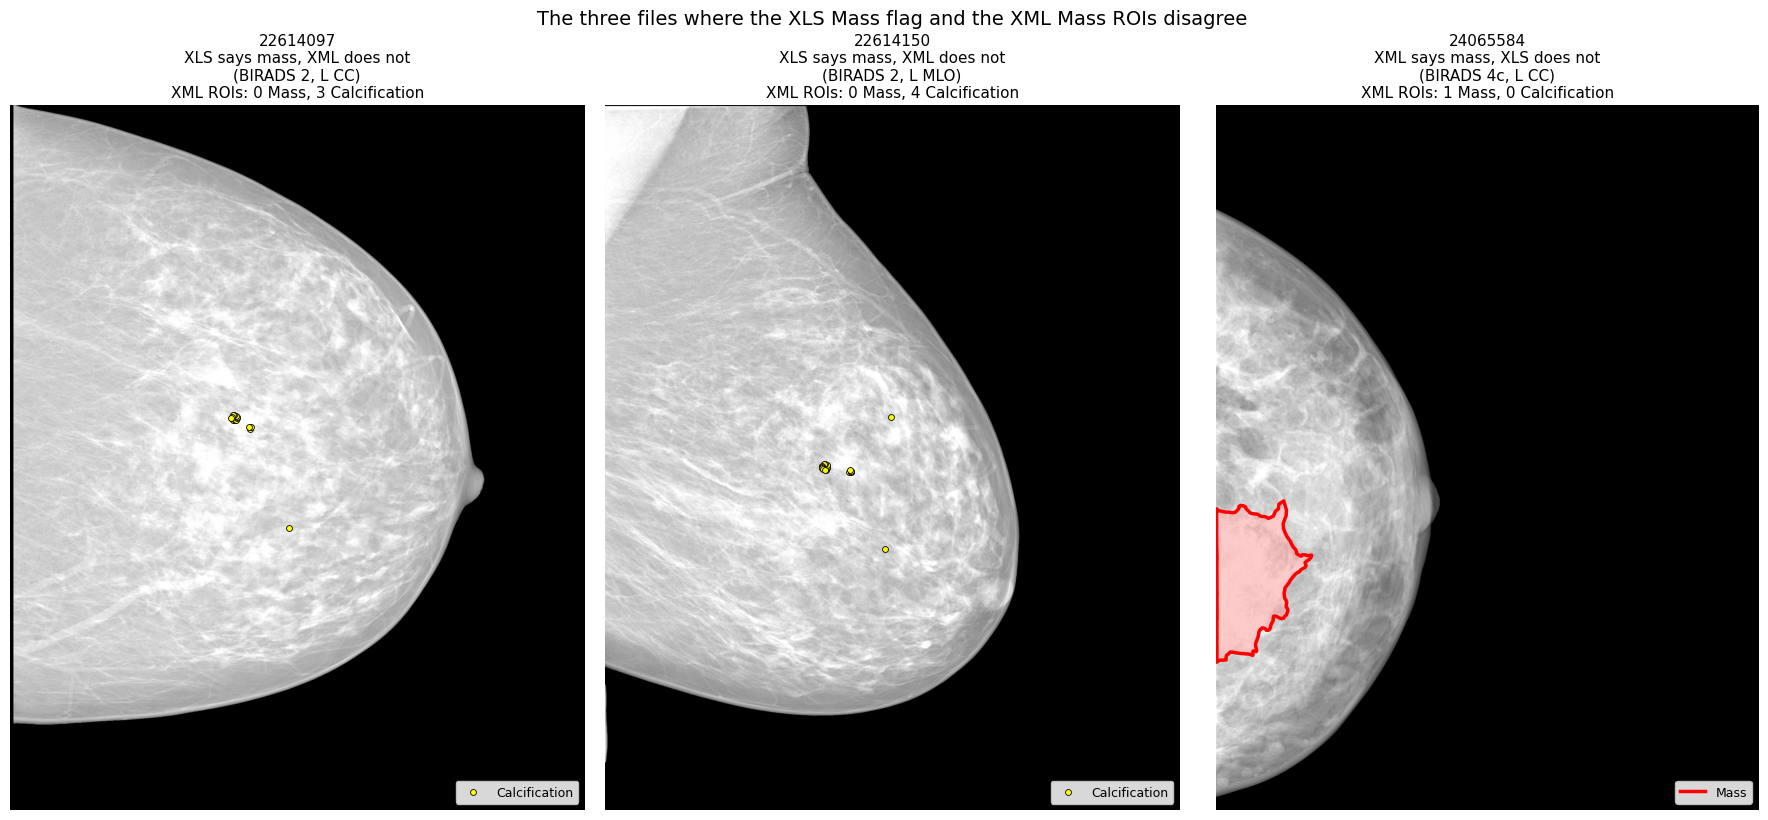

In [8]:
def parse_full_xml(xml_path: Path):
    """Return a list of (name, points_xy_array) for every ROI in an OsiriX plist."""
    with open(xml_path, "rb") as f:
        d = plistlib.load(f)
    out = []
    for img in d.get("Images", []):
        for roi in img.get("ROIs", []):
            name = roi.get("Name", "<unnamed>")
            pts = []
            for s in roi.get("Point_px", []):
                nums = NUM_RE.findall(str(s))
                if len(nums) >= 2:
                    pts.append((float(nums[0]), float(nums[1])))
            out.append((name, np.array(pts, dtype=np.float64)))
    return out


# Disagreeing file_ids + a short note about which side flags them.
DISAGREE = [
    ("22614097", "XLS says mass, XML does not\n(BIRADS 2, L CC)"),
    ("22614150", "XLS says mass, XML does not\n(BIRADS 2, L MLO)"),
    ("24065584", "XML says mass, XLS does not\n(BIRADS 4c, L CC)"),
]

fig, axes = plt.subplots(1, len(DISAGREE), figsize=(6 * len(DISAGREE), 8))

for ax, (fid, note) in zip(axes, DISAGREE):
    dcm = find_dicom(fid)
    img = load_dicom_norm(dcm)

    rois = parse_full_xml(XML_DIR / f"{fid}.xml")
    n_mass  = sum(1 for n, _ in rois if n == "Mass")
    n_calc  = sum(1 for n, _ in rois if n == "Calcification")
    n_other = sum(1 for n, _ in rois if n not in ("Mass", "Calcification"))

    ax.imshow(img, cmap="gray", vmin=0, vmax=1)

    for name, pts in rois:
        if pts.shape[0] == 0:
            continue
        if name == "Mass":
            # Mass polygons: draw the closed outline + a semi-transparent fill.
            if pts.shape[0] >= 3:
                closed = np.vstack([pts, pts[:1]])
                ax.plot(closed[:, 0], closed[:, 1], "r-", linewidth=2.5, label="Mass")
                ax.fill(closed[:, 0], closed[:, 1], color="red", alpha=0.20)
        elif name == "Calcification":
            # Calcifications are typically single points or tiny clusters.
            ax.scatter(pts[:, 0], pts[:, 1], c="yellow", s=18, marker="o",
                       edgecolor="black", linewidth=0.6, label="Calcification")
        else:
            ax.scatter(pts[:, 0], pts[:, 1], c="cyan", s=12, label=name)

    # De-duplicate the legend
    handles, labels = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels):
        seen.setdefault(l, h)
    if seen:
        ax.legend(seen.values(), seen.keys(), loc="lower right", fontsize=9,
                  framealpha=0.85)

    ax.set_title(
        f"{fid}\n{note}\nXML ROIs: {n_mass} Mass, {n_calc} Calcification"
        + (f", {n_other} other" if n_other else ""),
        fontsize=11,
    )
    ax.axis("off")

plt.suptitle(
    "The three files where the XLS Mass flag and the XML Mass ROIs disagree",
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.show()


### 6.1 What we see in each panel

- **`22614097` (L CC).** Multiple small yellow markers cluster in the central part of the breast. These are the three calcification ROIs from the XML. No red polygon is anywhere on the image — the XML annotator did not draw a mass outline, even though the XLS flagged the case. If the supposed mass exists in this image, it is co-located with or merged into the calcification cluster.
- **`22614150` (L MLO).** Same patient as above, MLO view of the same breast. Four calcification markers, no mass polygon. Again the XML annotator chose not to outline a mass.
- **`24065584` (L CC).** A single large red mass polygon dominates the lower-central part of the breast — clearly a substantial lesion that the XML annotator outlined in detail. The XLS lesion columns for this case are entirely empty, yet the polygon is unambiguously a mass.

In other words: the XML disagreements aren't subtle. For `22614097`/`22614150` the polygon simply does not exist; for `24065584` there is a large polygon the XLS overlooked.


### 6.2 Why we use the XML annotations rather than the XLS `Mass` column

For the project's mass classification task we need three things from each mass-bearing file:
1. The file_id, to load the DICOM.
2. A polygon outlining the lesion, so we can crop a patch.
3. A benign/malignant label.

The XLS gives us (1) and (3) for 108 files but **no spatial information**. The XML gives us all three for 107 files, with the polygon being the bottleneck. The pipeline can only crop where there is a polygon to crop from, so:

- The **two XLS-only files** (`22614097`, `22614150`) are excluded *not because we decided to exclude them*, but because there is no Mass ROI to extract a patch from. Both are BIRADS 2, so the practical loss is small — these would have been low-acuity benign samples.
- The **one XML-only file** (`24065584`) is included precisely because the XML provides the polygon the XLS lacked. This is a BIRADS 4c case, which is exactly the kind of suspicious-for-malignancy sample the mass classifier benefits from seeing. Switching to the XLS as the source-of-truth would lose this file.

So the choice of XML is forced by the pipeline's requirements (we need polygons), and on the merits the disagreements work in our favour: we drop two benign cases without polygons and we gain one high-acuity malignant case the XLS missed. The net 107-vs-108 difference is therefore not a problem with our pipeline — it is a real inter-annotator inconsistency in the INbreast dataset itself, and we are using the source that gives us the spatial data we need.

This audit, together with the pectoral-mask comparison in Sections 1–4, is the basis for the choices recorded in the project's data-quality discussion (`report/main.tex`, §4).


file_id=50994354, roi_index=0, label=malignant, BI-RADS=4a
preprocessed image shape: (3328, 2560)
Step 1.2 bbox: y=[806, 1098), x=[2214, 2483)
clamped crop shape: (292, 269)
preprocessed crop max: 0.000000
breast-mask pixels inside bbox: 0


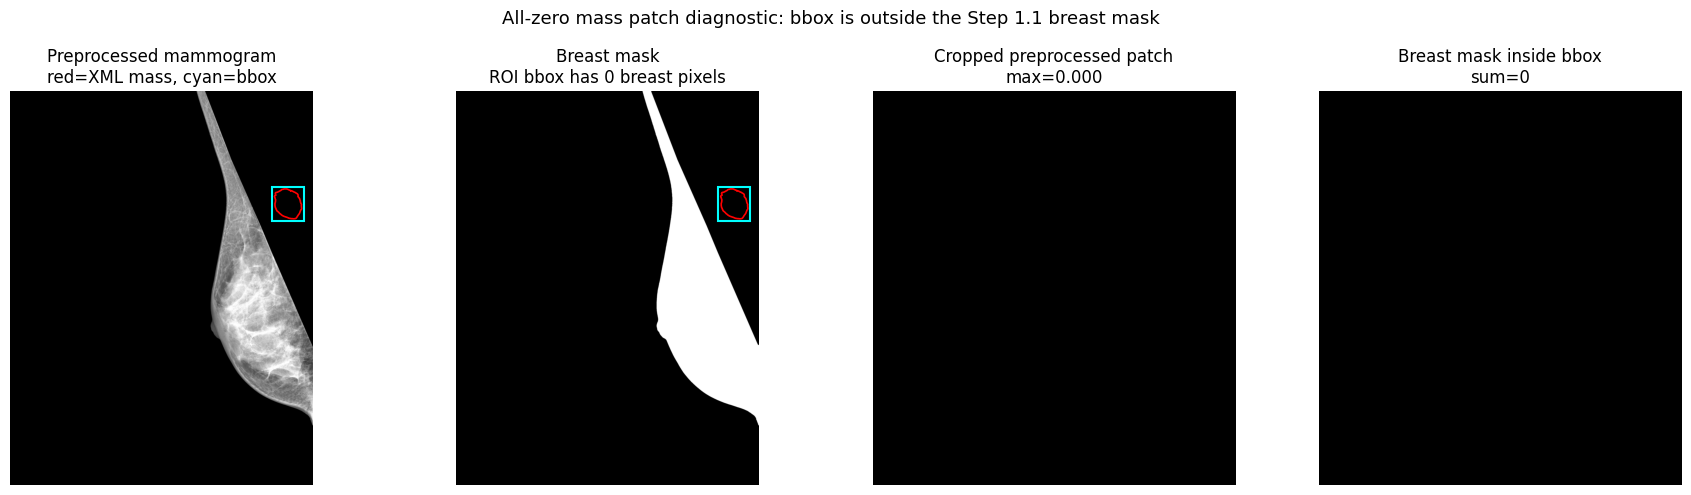

In [9]:
# Visualise why mass ROI 50994354 becomes an all-zero downstream patch.
# Read-only diagnostic: no files are written.

ZERO_FID = "50994354"
ZERO_ROI_INDEX = 0

mass_index = pd.read_csv(ROOT / "data" / "outputs" / "masses" / "mass_index.csv")
preproc_index = pd.read_csv(ROOT / "data" / "outputs" / "preprocessed" / "preproc_index.csv")

zero_row = mass_index[
    (mass_index["file_id"].astype(str) == ZERO_FID)
    & (mass_index["roi_index"].astype(int) == ZERO_ROI_INDEX)
].iloc[0]

pre_row = preproc_index[preproc_index["stem"].str.startswith(ZERO_FID)].iloc[0]

def _resolve_project_path(path_like):
    """Resolve notebook-relative paths such as '../data/...' against ROOT."""
    s = str(path_like)
    if s.startswith("../"):
        return ROOT / s[3:]
    return Path(s) if Path(s).is_absolute() else ROOT / s

pre_img = np.load(_resolve_project_path(pre_row["final_npy"])).astype(np.float32)
breast_mask = np.load(_resolve_project_path(pre_row["breast_mask_npy"])).astype(bool)

# Recover the XML Mass polygon for the same ROI. Step 1.2 numbers Mass ROIs
# in the order they appear after filtering ROIs with name == 'Mass'.
all_rois = parse_full_xml(_resolve_project_path(zero_row["xml_path"]))
mass_rois = [(name, pts) for name, pts in all_rois if str(name).strip().lower() == "mass"]
_, mass_pts = mass_rois[int(zero_row["roi_index"])]

H, W = pre_img.shape
y0, y1, x0, x1 = [int(zero_row[k]) for k in ["y0", "y1", "x0", "x1"]]
# Step 2 recropping clamps the bbox to image bounds and then resizes.
y0c, y1c = max(0, y0), min(H, y1)
x0c, x1c = max(0, x0), min(W, x1)
pre_crop = pre_img[y0c:y1c, x0c:x1c]
mask_crop = breast_mask[y0c:y1c, x0c:x1c]

print(f"file_id={ZERO_FID}, roi_index={ZERO_ROI_INDEX}, label={zero_row['label']}, BI-RADS={zero_row['birads']}")
print(f"preprocessed image shape: {pre_img.shape}")
print(f"Step 1.2 bbox: y=[{y0}, {y1}), x=[{x0}, {x1})")
print(f"clamped crop shape: {pre_crop.shape}")
print(f"preprocessed crop max: {float(pre_crop.max()) if pre_crop.size else np.nan:.6f}")
print(f"breast-mask pixels inside bbox: {int(mask_crop.sum()) if mask_crop.size else 0}")

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(pre_img, cmap="gray", vmin=0, vmax=1)
axes[0].plot(mass_pts[:, 0], mass_pts[:, 1], color="red", linewidth=1.2)
axes[0].add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="cyan", linewidth=1.5))
axes[0].set_title("Preprocessed mammogram\nred=XML mass, cyan=bbox")
axes[0].axis("off")

axes[1].imshow(breast_mask, cmap="gray")
axes[1].plot(mass_pts[:, 0], mass_pts[:, 1], color="red", linewidth=1.2)
axes[1].add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="cyan", linewidth=1.5))
axes[1].set_title("Breast mask\nROI bbox has 0 breast pixels")
axes[1].axis("off")

axes[2].imshow(pre_crop, cmap="gray", vmin=0, vmax=1)
axes[2].set_title(f"Cropped preprocessed patch\nmax={float(pre_crop.max()) if pre_crop.size else np.nan:.3f}")
axes[2].axis("off")

axes[3].imshow(mask_crop, cmap="gray")
axes[3].set_title(f"Breast mask inside bbox\nsum={int(mask_crop.sum()) if mask_crop.size else 0}")
axes[3].axis("off")

plt.suptitle("All-zero mass patch diagnostic: bbox is outside the Step 1.1 breast mask", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Summary — both audits together

Putting the two audits side by side:

- **Pectoral muscle masks (Sections 1–4).** Two sources cover an almost-identical set of files (199 in common, 5 differing). On the files they share, the two sources use visibly different annotation styles: GitHub draws coarse triangular regional masks (3–8 vertices), Kaggle draws fine muscle-boundary outlines (20–40 vertices). The pipeline uses the **GitHub source** (Aliniya 2023) because it's the one wired into Step 1.1 and its more conservative coverage removes a small amount of extra non-breast pixels at the boundary. Either source would work; the downstream effect on the tissue classifier is expected to be small because Step 1.1's Otsu breast mask handles non-breast pixels regardless of which pectoral mask is applied, and Step 1.3's patch sampler enforces a containment threshold that suppresses patches straddling the muscle edge.
- **Lesion annotations (Sections 5–6).** The XML and the XLS agree on 106 files and disagree on 3 (2 XLS-only — both BIRADS 2, the OsiriX annotator drew only calcifications, no Mass polygon to crop from; 1 XML-only — BIRADS 4c, the XLS lesion columns are empty but the XML annotator drew an unambiguous Mass polygon). The pipeline uses the **XML** because Step 1.2 needs polygon coordinates to crop patches; the XLS Mass column is a binary flag with no spatial data. On the merits the disagreements work in our favour: we drop two low-acuity benign cases that had no polygon, and we gain one high-acuity malignant case the XLS overlooked.

In both cases the disagreements are properties of the INbreast dataset itself (different annotators, different annotation passes), not bugs in our pipeline. The choices of source are deliberate, justified by the audits above, and recorded in the project report (`report/main.tex` §4 — both the preprocessing section and the annotation-source-audit subsection of the discussion reference this notebook).

Nothing is saved by this notebook — it is purely an inspection. The pectoral-mask choice is acted on in Step 1.1; the lesion-annotation choice is acted on in Step 1.2.
